<div style="background-color: lightblue; padding: 20px; border-radius: 15px; border: 2px solid #F0F8FF; font-family: 'Arial', sans-serif; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">

<h2 style="text-align:center; color: #ffffff; font-size: 24px; font-weight: bold; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.3);">Customer Segmentation</h2>

</div>


<div style="background-color: #f7f9fc; padding: 20px; border-radius: 10px; border: 3px solid lightblue; font-family: Arial, sans-serif;">

<h2 style="text-align:center; color:#2980b9;"> About the Project</h2>

<p style="font-size: 16px; color: #34495e;">
    <strong>Customer Personality Analysis</strong> delves into understanding a company’s ideal customers on a profound level. By gaining insights into their identities, preferences, and behaviors, businesses can tailor their products to meet the distinct needs of various customer groups.
</p>

<p style="font-size: 16px; color: #34495e;">
    In this project, we explore these insights to help businesses move beyond mere numbers. By leveraging this analysis, companies can refine their products and marketing strategies to resonate more deeply with specific customer segments. For instance, rather than casting a wide net, the company can zero in on the group most likely to embrace a new product, resulting in more targeted and impactful efforts.
</p>

</div>


<div style="background-color: #f9fbfd; padding: 20px; border-radius: 10px; border: 3px solid lightblue; font-family: Arial, sans-serif;">

<h2 style="text-align:center; color:#2980b9;">📋 Customer Data Attributes</h2>

<h3 style="color: #2980b9;">👤 People</h3>
<ul style="font-size: 16px; color: #2c3e50; list-style-type: none; padding-left: 0;">
    <li><strong>ID:</strong> Customer's unique identifier </li>
    <li><strong>Year_Birth:</strong> Customer's birth year </li>
    <li><strong>Education:</strong> Customer's education level </li>
    <li><strong>Marital_Status:</strong> Customer's marital status </li>
    <li><strong>Income:</strong> Yearly household income </li>
    <li><strong>Kidhome:</strong> Number of children in household </li>
    <li><strong>Teenhome:</strong> Number of teenagers in household </li>
    <li><strong>Dt_Customer:</strong> Enrollment date with the company </li>
    <li><strong>Recency:</strong> Days since last purchase </li>
    <li><strong>Complain:</strong> 1 if the customer complained in the last 2 years, 0 otherwise </li>
</ul>

<h3 style="color: #e67e22;">🛍️ Products</h3>
<ul style="font-size: 16px; color: #2c3e50; list-style-type: none; padding-left: 0;">
    <li><strong>MntWines:</strong> Amount spent on wine in the last 2 years </li>
    <li><strong>MntFruits:</strong> Amount spent on fruits in the last 2 years </li>
    <li><strong>MntMeatProducts:</strong> Amount spent on meat in the last 2 years </li>
    <li><strong>MntFishProducts:</strong> Amount spent on fish in the last 2 years </li>
    <li><strong>MntSweetProducts:</strong> Amount spent on sweets in the last 2 years </li>
    <li><strong>MntGoldProds:</strong> Amount spent on gold in the last 2 years </li>
</ul>

<h3 style="color: #c0392b;"> Promotion</h3>
<ul style="font-size: 16px; color: #2c3e50; list-style-type: none; padding-left: 0;">
    <li><strong>NumDealsPurchases:</strong> Purchases made with a discount </li>
    <li><strong>AcceptedCmp1-5:</strong> Whether the customer accepted offers in campaigns 1-5 </li>
    <li><strong>Response:</strong> 1 if accepted the last campaign offer, 0 otherwise </li>
</ul>

<h3 style="color: #16a085;"> Place</h3>
<ul style="font-size: 16px; color: #2c3e50; list-style-type: none; padding-left: 0;">
    <li><strong>NumWebPurchases:</strong> Purchases made through the website </li>
    <li><strong>NumCatalogPurchases:</strong> Purchases made using a catalog </li>
    <li><strong>NumStorePurchases:</strong> Purchases made in physical stores </li>
    <li><strong>NumWebVisitsMonth:</strong> Website visits in the last month </li>
</ul>

<h3 style="color: #8e44ad;">🎯 Target</h3>
<p style="font-size: 16px; color: #34495e;">
    Perform <strong>clustering</strong> to summarize customer segments and help the firm better understand different customer behaviors.
</p>

</div>


<div style="background-color: lightblue; padding: 20px; border-radius: 15px; border: 2px solid #F0F8FF; font-family: 'Arial', sans-serif; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">

<h2 style="text-align:center; color: #ffffff; font-size: 24px; font-weight: bold; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.3);">Import important libraries</h2>

</div>

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
from scipy.stats import zscore



<div style="background-color: lightblue; padding: 20px; border-radius: 15px; border: 2px solid #F0F8FF; font-family: 'Arial', sans-serif; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">

<h2 style="text-align:center; color: #ffffff; font-size: 24px; font-weight: bold; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.3);">Load Data</h2>

</div>


In [2]:
data = pd.read_csv('/kaggle/input/customer-personality-analysis/marketing_campaign.csv', sep='\t')
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


<div style="background-color: lightblue; padding: 20px; border-radius: 15px; border: 2px solid #F0F8FF; font-family: 'Arial', sans-serif; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">

<h2 style="text-align:center; color: #ffffff; font-size: 24px; font-weight: bold; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.3);">🔍 Explore Data</h2>

</div>



In [3]:
data.shape

(2240, 29)

In [4]:
data.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')>

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
round(data.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.16,3246.66,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.81,11.98,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.25,25173.08,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.44,0.54,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.51,0.54,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.11,28.96,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.94,336.60,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.30,39.77,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.95,225.72,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.53,54.63,0.0,3.00,12.0,50.00,259.0


In [7]:
d_null=data.isnull().sum()
d_null[d_null>0]

Income    24
dtype: int64

In [8]:
d_null=data.isnull().sum()
d_null[d_null>0]/data.shape[0]*100


Income    1.071429
dtype: float64

In [9]:
data[data.Income.isna()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,...,6,0,0,0,0,0,0,3,11,0


In [10]:
data.duplicated().sum()

0

<div style="background-color: #f7f9fb; padding: 20px; border-radius: 10px; border: 3px solid lightblue; font-family: Arial, sans-serif;">

<h2 style="text-align:center; color:#2c3e50;">📊 Data Exploration Summary</h2>

<h3 style="color: #2980b9;">Data Overview:</h3>
<p style="font-size: 16px; color: #2d3436;">
We found that the dataset consists of <strong>2,240 rows</strong> and <strong>29 columns</strong>. Most of the columns are numerical, except for <strong>Education</strong>, <strong>Marital_Status</strong>, and <strong>DT_customer</strong>.
</p>

<h3 style="color: #e67e22;">⚠️ Outliers:</h3>
<p style="font-size: 16px; color: #2d3436;">
As shown in the descriptive statistics, there are some outliers present in the data.
</p>

<h3 style="color: #c0392b;">🚩 Missing Values:</h3>
<p style="font-size: 16px; color: #2d3436;">
There are <strong>24 missing values</strong> in the <strong>Income</strong> column.
</p>

<h3 style="color: #16a085;">✅ Duplicate Rows:</h3>
<p style="font-size: 16px; color: #2d3436;">
There are no duplicate rows in the dataset.
</p>

</div>


<div style="background-color: lightblue; padding: 20px; border-radius: 15px; border: 2px solid #F0F8FF; font-family: 'Arial', sans-serif; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">

<h2 style="text-align:center; color: #ffffff; font-size: 24px; font-weight: bold; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.3);">🧹 Data cleaning </h2>

</div>



Text(0.5, 1.0, 'Distrbution of income')

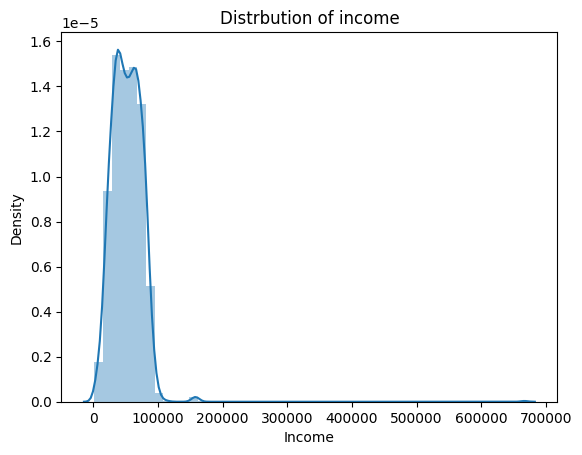

In [11]:
sns.distplot(data.Income)
plt.title('Distrbution of income')

**The graph shows that the income data is left-skewed, so we will fill the missing values using the median. This is a good approach because the median is less affected by the skewness and provides a better representation of central tendency for skewed data**

In [12]:
data.Income.fillna(data.Income.median(),inplace=True)

In [13]:
data.Income.info()

<class 'pandas.core.series.Series'>
RangeIndex: 2240 entries, 0 to 2239
Series name: Income
Non-Null Count  Dtype  
--------------  -----  
2240 non-null   float64
dtypes: float64(1)
memory usage: 17.6 KB


In [14]:
data[['Z_CostContact','Z_Revenue']].nunique()

Z_CostContact    1
Z_Revenue        1
dtype: int64

In [15]:
data[['Z_CostContact','Z_Revenue']].value_counts()

Z_CostContact  Z_Revenue
3              11           2240
Name: count, dtype: int64

**If columns contains the same value across all rows (as :'Z_CostContact','Z_Revenue') it is typically preferable to drop it, as it doesn't contribute any meaningful information or variation to the dataset and it doesn't contribute anything in model buliding .**

In [16]:
data.drop(columns=['Z_CostContact','Z_Revenue'],inplace=True)

In [17]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='object')

**let's work on our object data type columns**

In [18]:
catg_col=data.select_dtypes(include='object')
catg_col

,Education,Marital_Status,Dt_Customer
0,Graduation,Single,04-09-2012
1,Graduation,Single,08-03-2014
2,Graduation,Together,21-08-2013
3,Graduation,Together,10-02-2014
4,PhD,Married,19-01-2014
...,...,...,...
2235,Graduation,Married,13-06-2013
2236,PhD,Together,10-06-2014
2237,Graduation,Divorced,25-01-2014
2238,Master,Together,24-01-2014


In [19]:
data.Dt_Customer.sort_values()

664     01-01-2013
1784    01-01-2013
1972    01-01-2013
1277    01-01-2013
742     01-01-2014
           ...    
1097    31-10-2012
1694    31-12-2012
1202    31-12-2013
750     31-12-2013
36      31-12-2013
Name: Dt_Customer, Length: 2240, dtype: object

In [20]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'],format='%d-%m-%Y')

In [21]:
data.Dt_Customer.info()

<class 'pandas.core.series.Series'>
RangeIndex: 2240 entries, 0 to 2239
Series name: Dt_Customer
Non-Null Count  Dtype         
--------------  -----         
2240 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 17.6 KB


In [22]:
dates=[]
for date in data.Dt_Customer:
    date=date.date()
    dates.append(date)
print("the newest customer's enrolment date in records: ",max(dates))
print("the oldest customer's enrolment date in records: ",min(dates))


the newest customer's enrolment date in records:  2014-06-29
the oldest customer's enrolment date in records:  2012-07-30


In [23]:
latest_date = data['Dt_Customer'].max()
data['days'] = (latest_date - data['Dt_Customer']).dt.days
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,4,7,0,0,0,0,0,0,1,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,5,0,0,0,0,0,0,0,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,10,4,0,0,0,0,0,0,0,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,4,6,0,0,0,0,0,0,0,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,6,5,0,0,0,0,0,0,0,161


In [24]:
data.days.describe()

count    2240.000000
mean      353.582143
std       202.122512
min         0.000000
25%       180.750000
50%       355.500000
75%       529.000000
max       699.000000
Name: days, dtype: float64

In [25]:
# Standardize 'Education' into 3 broader groups
data['Education'] = data['Education'].replace(['PhD', 'Master','2n Cycle'], 'Postgraduate')  
data['Education'] = data['Education'].replace(['Graduation'], 'Graduate')
data['Education'] = data['Education'].replace(['Basic'], 'Undergraduate')


In [26]:
education=data.Education.value_counts()
data_education=pd.DataFrame(education)
df_education=data_education.reset_index()
colors = [ 'lightpink', 'plum', 'yellow']
fig = px.pie(df_education, values='count', names='Education',color_discrete_sequence=colors)
fig.show()


In [27]:
data.Marital_Status.value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [28]:
data['Marital_Status'] = data['Marital_Status'].replace(['Married', 'Together'], 'Partner')
data['Marital_Status'] = data['Marital_Status'].replace(['Divorced', 'Widow', 'Alone', 'YOLO', 'Absurd'], 'Single')

In [29]:
Marital_Status=data.Marital_Status.value_counts()
data_Marital_Status=pd.DataFrame(Marital_Status)
df_Marital_Status=data_Marital_Status.reset_index()
colors = [ 'lightpink','lightblue']
fig = px.pie(df_Marital_Status, values='count', names='Marital_Status', color_discrete_sequence=colors)
fig.show()


**let's Combining columns together to reduce the number of Features**

In [30]:
data['kids']=data['Teenhome']+data['Kidhome']

<Axes: xlabel='kids'>

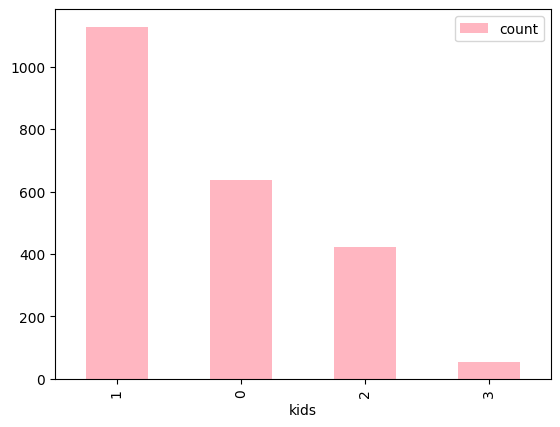

In [31]:
All_kids=data.kids.value_counts()
data_All_kids=pd.DataFrame(All_kids)
df_All_kids=data_All_kids.reset_index()
colors = [ 'lightpink']
df_All_kids.plot.bar(x='kids',y='count',color=colors)

In [32]:
data['Expenses'] = data['MntWines'] + data['MntFruits'] + data['MntMeatProducts'] + data['MntFishProducts'] + data['MntSweetProducts'] + data['MntGoldProds']


<Axes: xlabel='Expenses', ylabel='Density'>

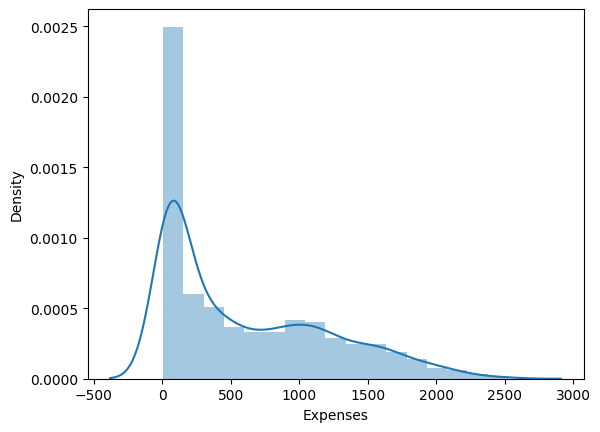

In [33]:
sns.distplot(data['Expenses'])

In [34]:
data['All_AcceptedCmp'] = data['AcceptedCmp1'] + data['AcceptedCmp2'] + data['AcceptedCmp3'] + data['AcceptedCmp4'] + data['AcceptedCmp5']


In [35]:
All_AcceptedCmp=data.All_AcceptedCmp.value_counts()
data_All_AcceptedCmp=pd.DataFrame(All_AcceptedCmp)
df_All_AcceptedCmp=data_All_AcceptedCmp.reset_index()
fig = px.bar(df_All_AcceptedCmp, y='count', x='All_AcceptedCmp', color_discrete_sequence=colors,title= 'all accepted cmp comparison ' )
fig.show()

In [36]:
data['All_NumPurchases'] = data['NumWebPurchases'] + data['NumCatalogPurchases'] + data['NumStorePurchases'] + data['NumDealsPurchases']

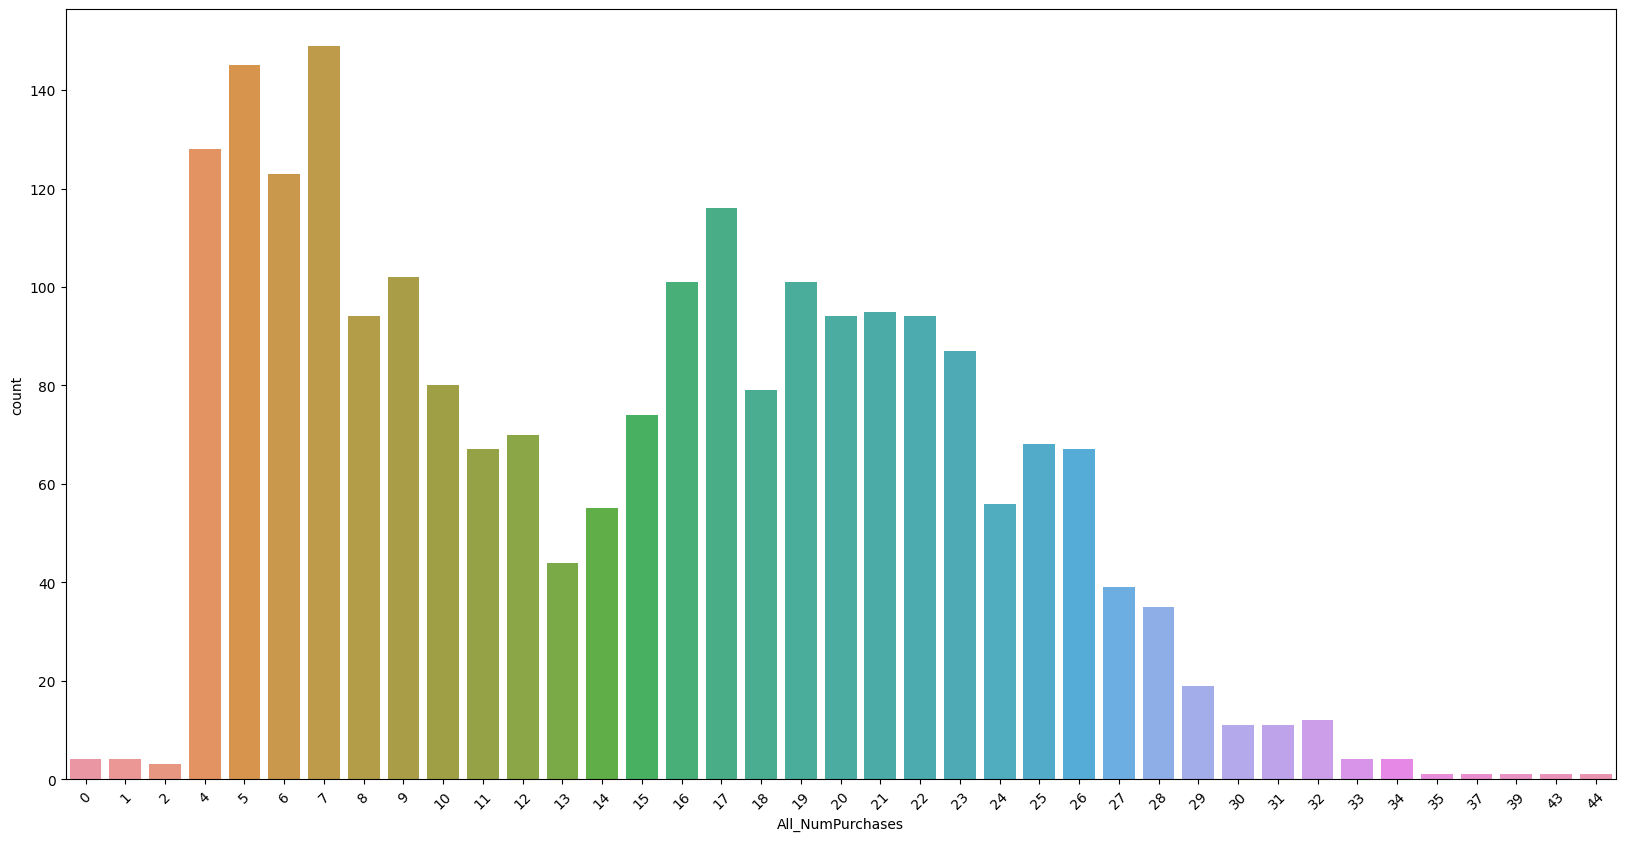

In [37]:
plt.figure(figsize=(20,10))
sns.countplot(data=data,x='All_NumPurchases')
plt.xticks(rotation=45)
plt.show()

In [38]:
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,days,kids,Expenses,All_AcceptedCmp,All_NumPurchases
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,1,663,0,1617,0,25
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,113,2,27,0,6
2,4141,1965,Graduate,Partner,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,312,0,776,0,21
3,6182,1984,Graduate,Partner,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,139,1,53,0,8
4,5324,1981,Postgraduate,Partner,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,161,1,422,0,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduate,Partner,61223.0,0,1,2013-06-13,46,709,...,0,0,0,0,0,381,1,1341,0,18
2236,4001,1946,Postgraduate,Partner,64014.0,2,1,2014-06-10,56,406,...,0,1,0,0,0,19,3,444,1,22
2237,7270,1981,Graduate,Single,56981.0,0,0,2014-01-25,91,908,...,0,0,0,0,0,155,0,1241,1,19
2238,8235,1956,Postgraduate,Partner,69245.0,0,1,2014-01-24,8,428,...,0,0,0,0,0,156,1,843,0,23


In [39]:
data['Age']=2024-data['Year_Birth']

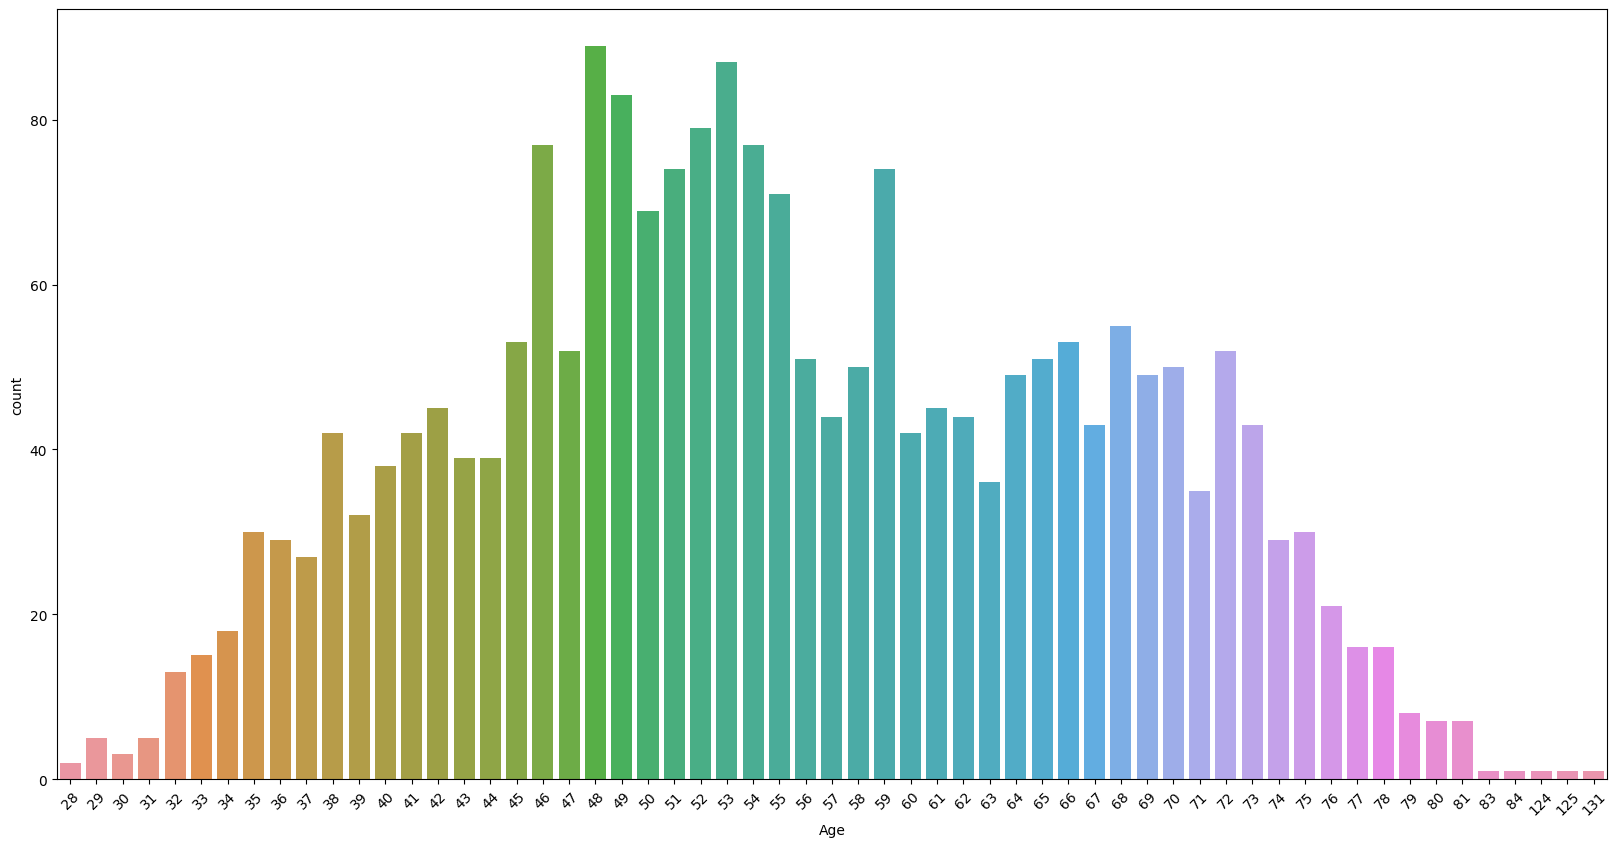

In [40]:
plt.figure(figsize=(20,10))
sns.countplot(data=data,x='Age')
plt.xticks(rotation=45)
plt.show()

<div style="background-color: #f7f9fc; padding: 20px; border-radius: 10px; border: 1px solid #dfe6e9; font-family: Arial, sans-serif;">

<h2 style="text-align:center; color:#2c3e50;">Data Preprocessing Summary </h2>

<h3 style="color: #2980b9;">🔄 Value Replacement:</h3>
<p style="font-size: 16px; color: #34495e;">
    We have standardized the <strong>Education</strong> column as follows:
    <ul>
        <li><strong>PhD</strong>, <strong>Master</strong>, and <strong>2n Cycle</strong> have been replaced with <strong>post graduate</strong>.</li>
        <li><strong>Basic</strong> has been replaced with <strong>under graduate</strong>.</li>
        <li><strong>Graduation</strong> remains as <strong>Graduation</strong>.</li>
    </ul>
    This results in the majority of data being categorized as either <strong>post graduate</strong> or <strong>under graduate</strong>.
</p>

<h3 style="color: #e67e22;">👫 Marital Status:</h3>
<p style="font-size: 16px; color: #34495e;">
    The <strong>Marital_Status</strong> column shows that most data falls into:
    <ul>
        <li><strong>Partner</strong> - 64.5%</li>
        <li><strong>Single</strong> - 35.5%</li>
    </ul>
</p>

<h3 style="color: #c0392b;"> 🧹 Handling Missing Values:</h3>
<p style="font-size: 16px; color: #34495e;">
    Missing values in the <strong>Income</strong> column have been handled by fill nulls with the median. This choice was made because the data is left-skewed, and the median is the most appropriate measure of central tendency in such cases.
</p>

<h3 style="color: #16a085;">🗑️ Dropping Columns:</h3>
<p style="font-size: 16px; color: #34495e;">
    Two columns ('Z_CostContact','Z_Revenue') with identical values across all rows have been identified and dropped, as they do not contribute any meaningful information to the model.
</p>

<h3 style="color: #8e44ad;">🔄 Data Type Transformation:</h3>
<p style="font-size: 16px; color: #34495e;">
    The <strong>DT_customer</strong> column, originally of type <strong>object</strong>, has been converted to <strong>datetime</strong> for proper handling and analysis of date-related data.
</p>

<h3 style="color:pink">🔗  Combining Columns:</h3>
<p style="font-size: 16px; color: #34495e;">
    Combining some Features To reduce dimensionality, This helps simplify the model while retaining essential information.
</p>
<h3 style="color: #3498db;"> ➕Adding New Columns:</h3>
<p style="font-size: 16px; color: #34495e;">
    New columns <strong>Age</strong> and <strong>Days_since_customer 📅</strong> have been created:
    <ul>
        <li><strong>Age</strong> is derived from the year of birth or a similar column to calculate the age of the customer.</li>
        <li><strong>Days_since_customer</strong> is calculated from the <strong>DT_customer</strong> column to find how many days have passed since the leatest customer joined.</li>
    </ul>
</p>
</div>


<div style="background-color: lightblue; padding: 20px; border-radius: 15px; border: 2px solid #F0F8FF; font-family: 'Arial', sans-serif; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">

<h2 style="text-align:center; color: #ffffff; font-size: 24px; font-weight: bold; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.3);">💡 EDA </h2>

</div>




In [41]:
data.columns=data.columns.str.lower()

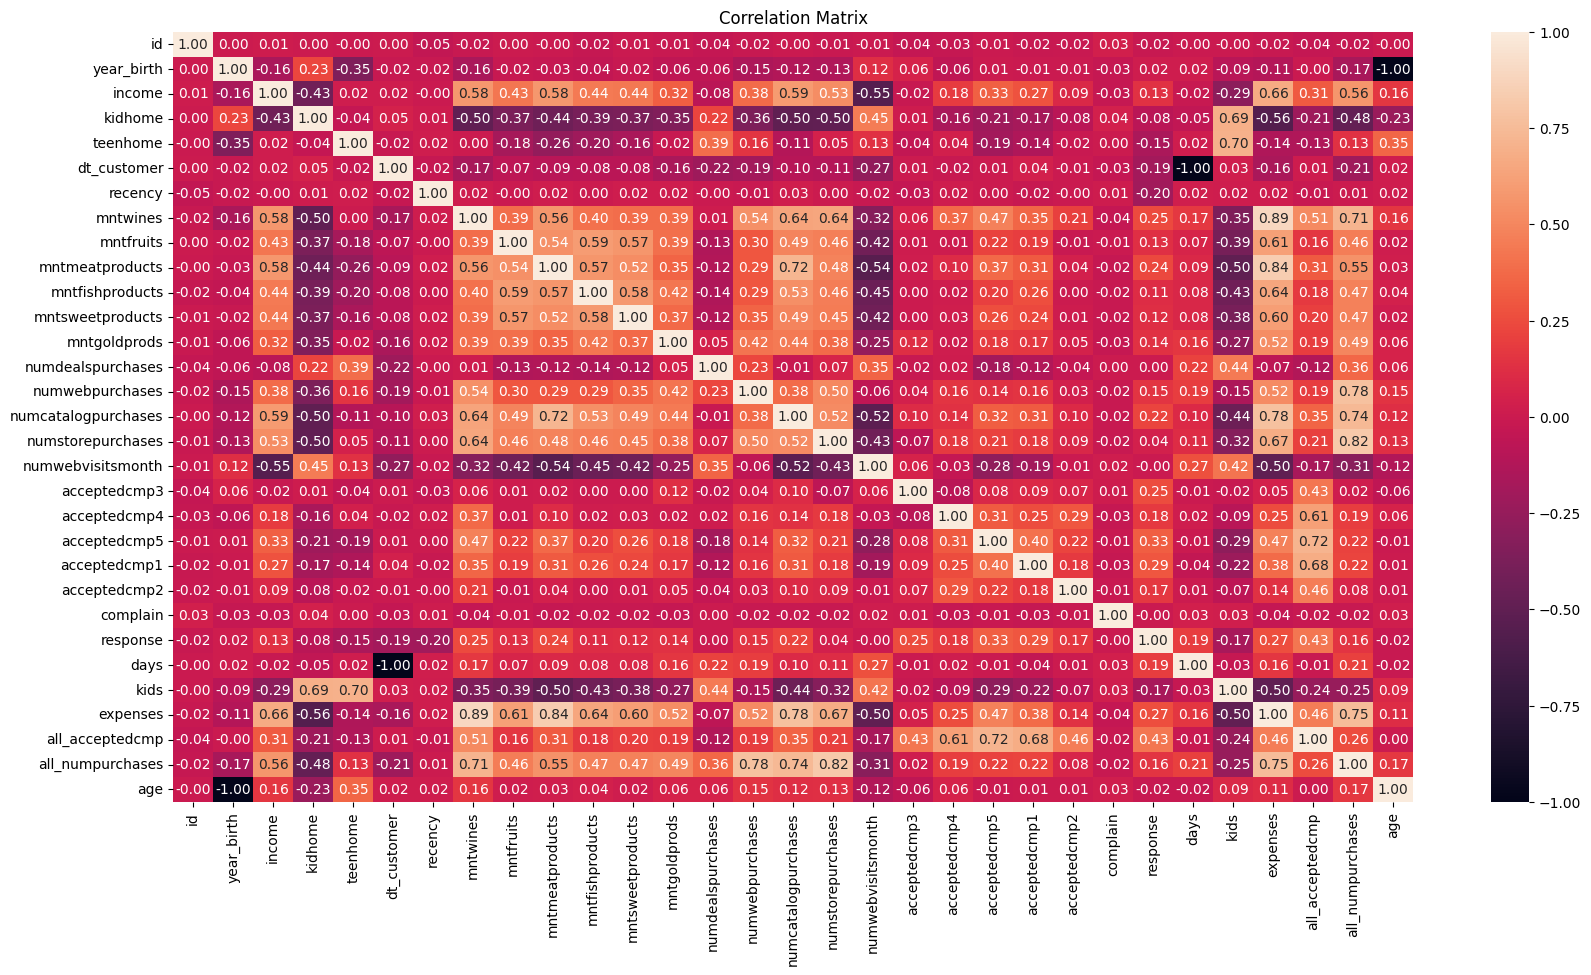

In [42]:
plt.figure(figsize=(20,10))
num_data=data.select_dtypes(exclude='object')
sns.heatmap(num_data.corr(),annot=True,fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [43]:
for col in data.columns:
    print(col,':',data[col].nunique())

id : 2240
year_birth : 59
education : 3
marital_status : 2
income : 1975
kidhome : 3
teenhome : 3
dt_customer : 663
recency : 100
mntwines : 776
mntfruits : 158
mntmeatproducts : 558
mntfishproducts : 182
mntsweetproducts : 177
mntgoldprods : 213
numdealspurchases : 15
numwebpurchases : 15
numcatalogpurchases : 14
numstorepurchases : 14
numwebvisitsmonth : 16
acceptedcmp3 : 2
acceptedcmp4 : 2
acceptedcmp5 : 2
acceptedcmp1 : 2
acceptedcmp2 : 2
complain : 2
response : 2
days : 663
kids : 4
expenses : 1054
all_acceptedcmp : 5
all_numpurchases : 39
age : 59


In [44]:
df_accepcmp=data[['acceptedcmp1','acceptedcmp2','acceptedcmp3', 'acceptedcmp4','acceptedcmp5']]
for col in df_accepcmp.columns:
    print(df_accepcmp[col].value_counts())

acceptedcmp1
0    2096
1     144
Name: count, dtype: int64
acceptedcmp2
0    2210
1      30
Name: count, dtype: int64
acceptedcmp3
0    2077
1     163
Name: count, dtype: int64
acceptedcmp4
0    2073
1     167
Name: count, dtype: int64
acceptedcmp5
0    2077
1     163
Name: count, dtype: int64


### expenses distribution 

<Axes: xlabel='expenses', ylabel='Density'>

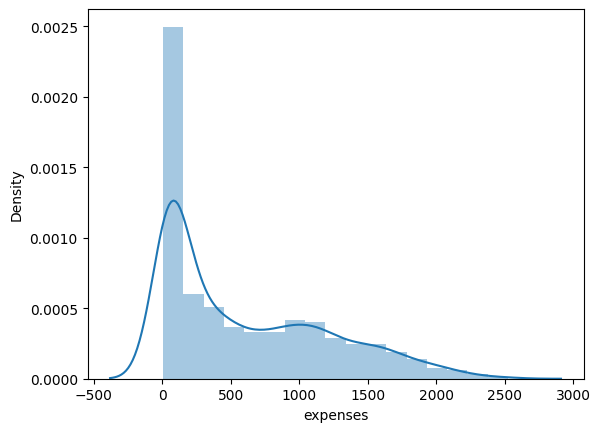

In [45]:
sns.distplot(data.expenses)

### How education impacts on expenses?

In [46]:
gr_education=data.groupby('education')['expenses'].median().to_frame().reset_index()
gr_education

,education,expenses
0,Graduate,414.0
1,Postgraduate,411.0
2,Undergraduate,57.0


In [47]:
fig=px.histogram(gr_education,x='education',y='expenses',title='how education impacts on expenses',color='education', color_discrete_sequence=['lightpink', 'plum','lightgreen'])
fig.show()

### how marital status impacts on expenses ?

In [48]:
gr_marital_status=data.groupby('marital_status')['expenses'].median().to_frame().reset_index()
gr_marital_status

,marital_status,expenses
0,Partner,395.5
1,Single,397.0


In [49]:

fig=px.histogram(data,x='marital_status',y='expenses',title='how marital status impacts on expenses',color='marital_status', color_discrete_sequence=['lightgreen','lightpink'])
fig.show()

### how kids impacts on expenses ?

In [50]:
gr_kids=data.groupby('kids')['expenses'].median().to_frame().reset_index()
gr_kids

,kids,expenses
0,0,1189.5
1,1,305.0
2,2,93.0
3,3,88.0


In [51]:
fig=px.bar(gr_kids,x='kids',y='expenses',title='how kids impacts on expenses',color='kids', color_continuous_scale=['lightgreen','lightpink','plum','yellow'])
fig.show()

### how all_acceptedcmp impacts on expenses?

In [52]:
gr_all_acceptedcmp=data.groupby('all_acceptedcmp')['expenses'].median().to_frame().reset_index()
gr_all_acceptedcmp

,all_acceptedcmp,expenses
0,0,253.0
1,1,916.0
2,2,1438.0
3,3,1720.0
4,4,1676.0


In [53]:
fig=px.bar(gr_all_acceptedcmp,x='all_acceptedcmp',y='expenses',title='how all_acceptedcmp impacts on expenses',color='all_acceptedcmp',  color_continuous_scale=['yellow','lightgreen','lightpink','plum','lightblue'],barmode='group')
fig.show()

In [54]:
gr_age=data.groupby('age')['expenses'].median().to_frame().reset_index()
gr_age

,age,expenses
0,28,69.0
1,29,960.0
2,30,1378.0
3,31,1216.0
4,32,241.0
5,33,836.0
6,34,95.5
7,35,82.5
8,36,269.0
9,37,369.0


In [55]:
fig=px.bar(gr_age,x='age',y='expenses',title='how all_acceptedcmp impacts on expenses',color='age', color_continuous_scale=['lightgreen','lightpink','plum','yellow','lightblue'],barmode='group')
fig.show()

<Axes: xlabel='days', ylabel='expenses'>

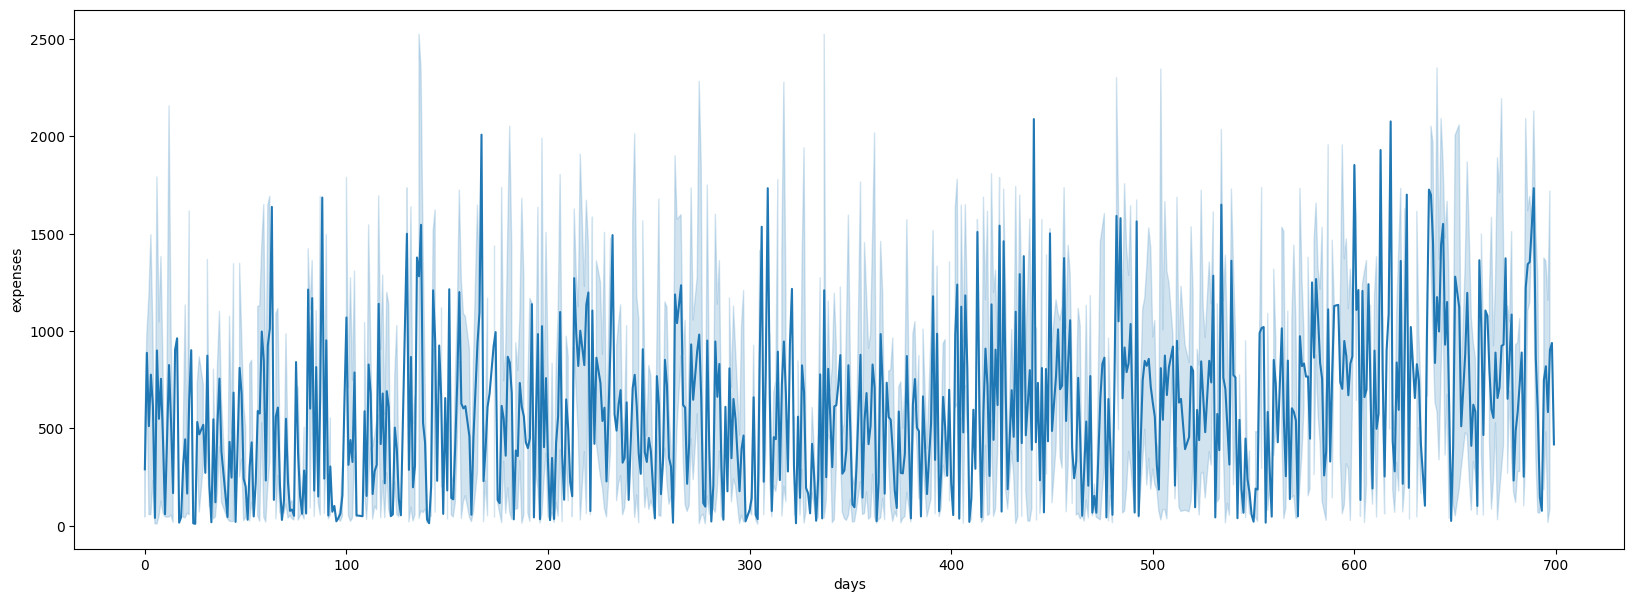

In [56]:
plt.figure(figsize=(20,7))
sns.lineplot(data=data,x='days',y='expenses')

<Axes: xlabel='days', ylabel='expenses'>

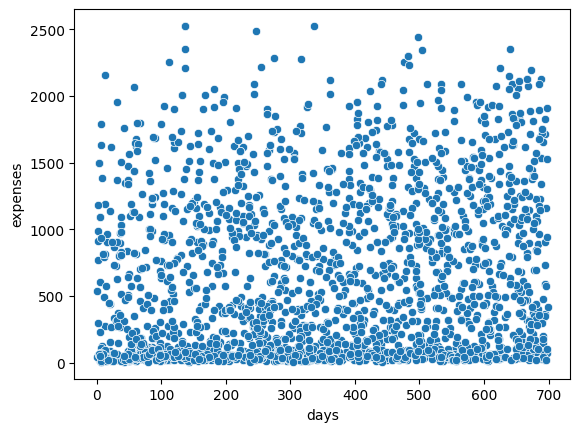

In [57]:
sns.scatterplot(data=data,x='days',y='expenses')

### Which marital status has high income ?

In [58]:
gr=data.groupby('marital_status',as_index=False)['income'].sum()
df_gr=pd.DataFrame(gr)
sort_df=df_gr.sort_values(by='income',ascending=False)
sort_df[0:1]


,marital_status,income
0,Partner,75557339.0


Text(0.5, 1.0, 'Marital Status by Income')

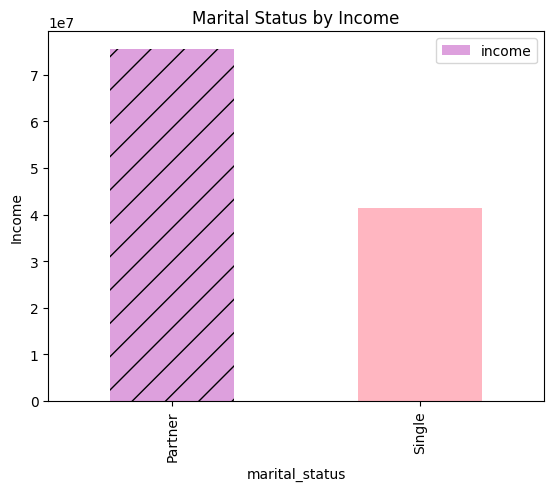

In [59]:
colors = [ 'plum', 'lightpink','orange','lightgreen','lightblue','yellow','blue','purple']
num_bars = len(df_gr)
bars = df_gr.plot.bar(x='marital_status', y='income', color=colors[:num_bars])
max_value = df_gr['income'].max()

for patch in bars.patches:
    if patch.get_height()==max_value:
        patch.set_hatch('/')
plt.ylabel('Income')
plt.title('Marital Status by Income')


### which matrial status takes max income ?

In [60]:
gr=data.groupby('marital_status',as_index=False)['income'].max()
df_gr=pd.DataFrame(gr)
sort_df=df_gr.sort_values(by='income',ascending=False)
sort_df[0:1]

,marital_status,income
0,Partner,666666.0


In [61]:
data_prodcut=data[['year_birth', 'education', 'marital_status', 'income', 'kidhome','teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits','mntmeatproducts', 'mntfishproducts', 'mntsweetproducts','mntgoldprods','age','complain']]
data_prodcut

,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,age,complain
0,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,67,0
1,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,70,0
2,1965,Graduate,Partner,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,59,0
3,1984,Graduate,Partner,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,40,0
4,1981,Postgraduate,Partner,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,43,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduate,Partner,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,57,0
2236,1946,Postgraduate,Partner,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,78,0
2237,1981,Graduate,Single,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,43,0
2238,1956,Postgraduate,Partner,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,68,0


### what is prodcut that has highest Amount spent in last 2 years ?

In [62]:
data_prod=data[['mntwines', 'mntfruits','mntmeatproducts', 'mntfishproducts', 'mntsweetproducts','mntgoldprods']].max()
sort_data=data_prod.sort_values(ascending=False)

sort_data

mntmeatproducts     1725
mntwines            1493
mntgoldprods         362
mntsweetproducts     263
mntfishproducts      259
mntfruits            199
dtype: int64

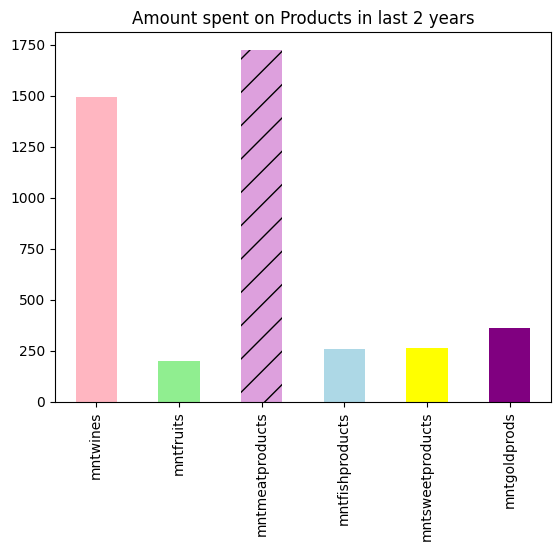

In [63]:
colors = ['lightpink', 'lightgreen', 'plum', 'lightblue', 'yellow', 'purple']
bars=data_prod.plot.bar(color=colors)
max_value=data_prod.max()
for patch in bars.patches:
    if patch.get_height()==max_value:
        patch.set_hatch('/')
plt.title('Amount spent on Products in last 2 years')        
plt.show()       


### what is prodcut that has highest Amount spent in last 2 years in each  marital status?

Text(0.5, 1.0, 'Total Amount spent on Products in last 2 years in each Marital Status ')

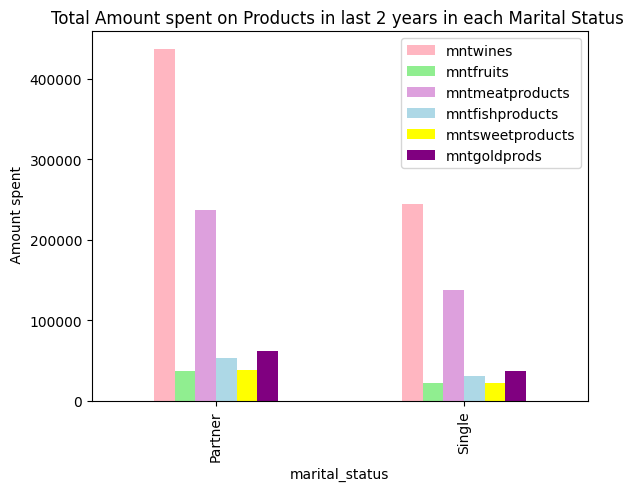

In [64]:
colors = [ 'lightpink','lightgreen' , 'plum', 'lightblue','yellow','purple']
prod_gr=data_prodcut.groupby('marital_status')[['mntwines', 'mntfruits','mntmeatproducts', 'mntfishproducts', 'mntsweetproducts','mntgoldprods']].sum().plot.bar(color=colors)
plt.ylabel(' Amount spent')
plt.title('Total Amount spent on Products in last 2 years in each Marital Status ')        


### what is prodcut that has highest Amount spent in last 2 years in each education level?

<Axes: xlabel='education'>

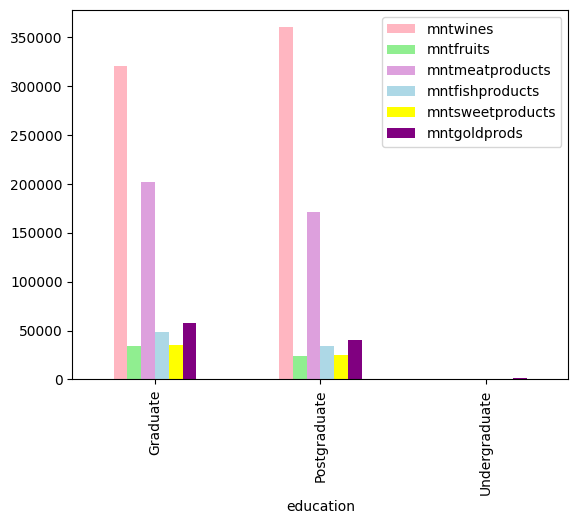

In [65]:
colors = [ 'lightpink','lightgreen' , 'plum', 'lightblue','yellow','purple']
prod_gr=data_prodcut.groupby('education')[['mntwines', 'mntfruits','mntmeatproducts', 'mntfishproducts', 'mntsweetproducts','mntgoldprods']].sum().plot.bar(color=colors)
prod_gr

### what is total kidhome & teenhome according to Customer's marital status?

In [66]:
print(data.kidhome.value_counts())
print(data.teenhome.value_counts())

kidhome
0    1293
1     899
2      48
Name: count, dtype: int64
teenhome
0    1158
1    1030
2      52
Name: count, dtype: int64


In [67]:
prod_gr=data_prodcut.groupby('marital_status')[['kidhome','teenhome']].sum()
prod_gr_df=pd.DataFrame(prod_gr)
prod_gr_df

,kidhome,teenhome
marital_status,,
Partner,655,749
Single,340,385


###  Number of children in each Marital Status

In [68]:
fig = px.histogram(data_prodcut, x='marital_status', color='kidhome',barmode='group',
                   color_discrete_sequence=['lightpink', 'lightgreen', 'plum'])
fig.show()

###  Number of Teenagers in each Marital Status

In [69]:
fig = px.histogram(data_prodcut, x='marital_status', color='teenhome',hover_data=['mntwines', 'mntfruits','mntmeatproducts', 'mntfishproducts', 'mntsweetproducts','mntgoldprods'] ,barmode='group',
                   color_discrete_sequence=['lightpink', 'lightgreen', 'plum'])
fig.show()

### what is total kidhome & teenhome according to Customer's Education?

<Axes: xlabel='education'>

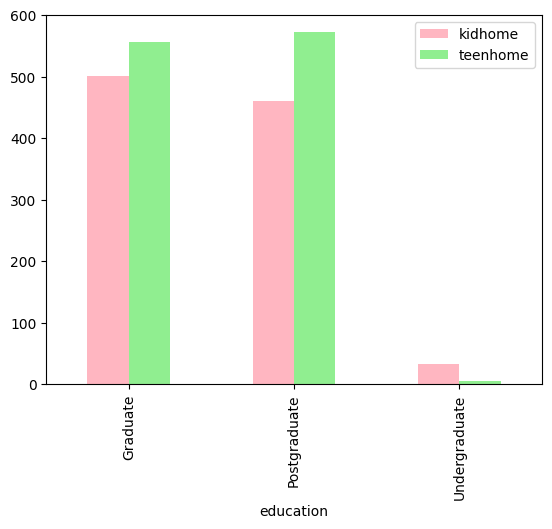

In [70]:
prod_gr=data_prodcut.groupby('education')[['kidhome','teenhome']].sum().plot.bar(color=colors)
prod_gr

###  Number of children in each Education level

In [71]:
fig = px.histogram(data_prodcut, x='education', y='kidhome',color='kidhome',hover_data=['mntwines', 'mntfruits','mntmeatproducts', 'mntfishproducts', 'mntsweetproducts','mntgoldprods'] ,barmode='group',
                   color_discrete_sequence=[ 'lightgreen','lightpink', 'plum'])
fig.show()

###  Number of Teenagers in each Education level

In [72]:
fig = px.histogram(data_prodcut, x='education', y='teenhome',color='teenhome',hover_data=['mntwines', 'mntfruits','mntmeatproducts', 'mntfishproducts', 'mntsweetproducts','mntgoldprods'] ,barmode='group',
                   color_discrete_sequence=['lightgreen','lightpink', 'plum'])
fig.show()

### what is highest number of complain in each marital status

<Axes: xlabel='marital_status'>

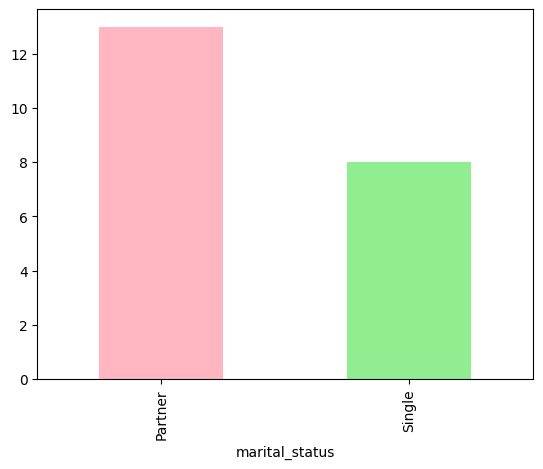

In [73]:
prod_gr=data_prodcut.groupby('marital_status')['complain'].sum().plot.bar(color=colors)
prod_gr

### what is highest customer income in marital status?

In [74]:
income_gr=data_prodcut.groupby('marital_status')['income'].max()
sort_data=income_gr.sort_values(ascending=False)
sort_data

marital_status
Partner    666666.0
Single     153924.0
Name: income, dtype: float64

Text(0.5, 1.0, 'highest customer income in each marital status')

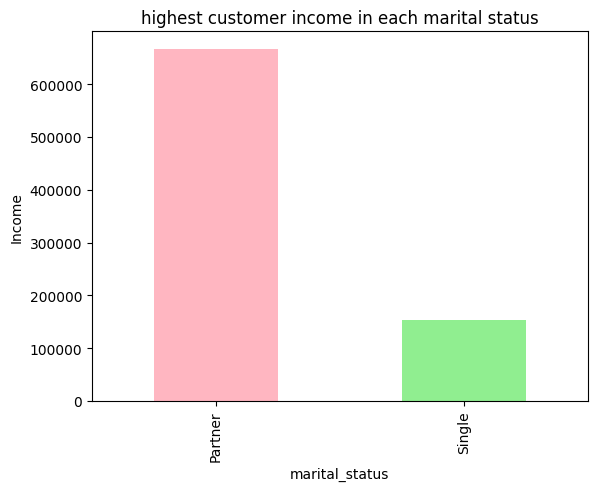

In [75]:
sort_data.plot.bar(color=colors)
plt.ylabel('Income')
plt.title('highest customer income in each marital status')

Text(0.5, 1.0, 'Highest total income in each marital status')

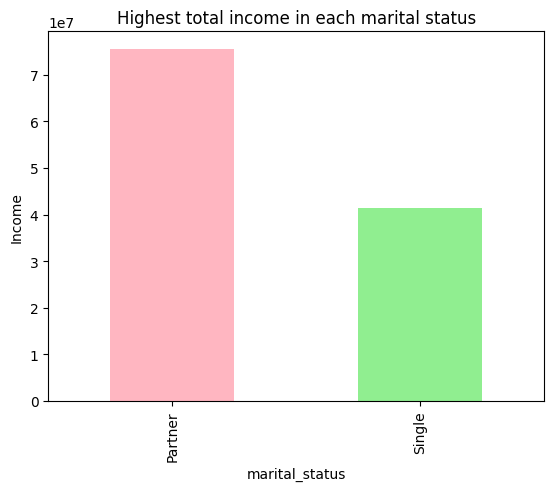

In [76]:
income_gr=data_prodcut.groupby('marital_status')['income'].sum().sort_values(ascending=False)
income_gr.plot.bar(color=colors)
plt.ylabel('Income')
plt.title('Highest total income in each marital status')

### what is highest customer income in eachEducation Level

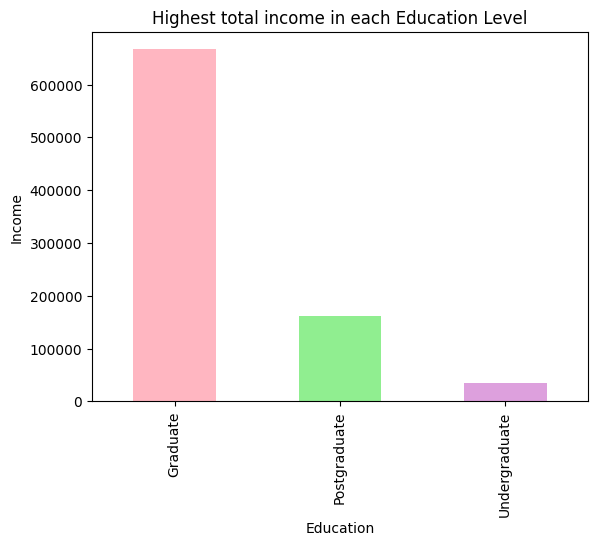

In [77]:
sort_data = data_prodcut.groupby('education')['income'].max().sort_values(ascending=False)

sort_data.plot.bar(color=colors)
plt.xlabel('Education')
plt.ylabel('Income')
plt.title('Highest total income in each Education Level')
plt.show()



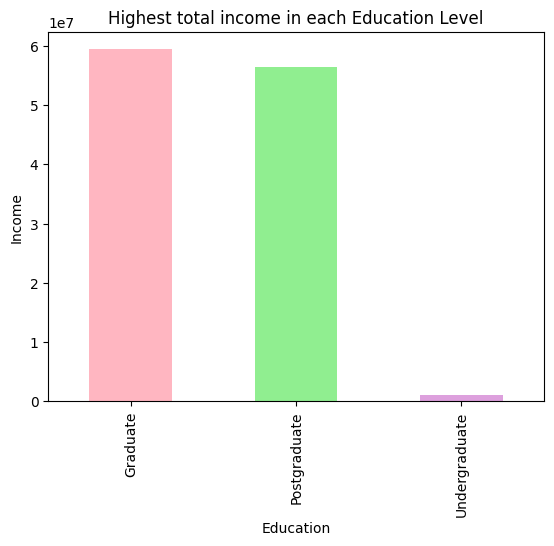

In [78]:
edu_gr=data_prodcut.groupby('education')['income'].sum().sort_values(ascending=False)
edu_gr.plot.bar(color=colors)
plt.xlabel('Education')
plt.ylabel('Income')
plt.title('Highest total income in each Education Level')
plt.show()

In [79]:
data.columns

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2', 'complain', 'response', 'days', 'kids', 'expenses',
       'all_acceptedcmp', 'all_numpurchases', 'age'],
      dtype='object')

In [80]:
df_accept=data[['id','age','numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2']]
df_accept 

,id,age,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2
0,5524,67,8,10,4,7,0,0,0,0,0
1,2174,70,1,1,2,5,0,0,0,0,0
2,4141,59,8,2,10,4,0,0,0,0,0
3,6182,40,2,0,4,6,0,0,0,0,0
4,5324,43,5,3,6,5,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,57,9,3,4,5,0,0,0,0,0
2236,4001,78,8,2,5,7,0,0,0,1,0
2237,7270,43,2,3,13,6,0,1,0,0,0
2238,8235,68,6,5,10,3,0,0,0,0,0


In [81]:
data.groupby('marital_status')[['numdealspurchases', 'numwebpurchases','numcatalogpurchases','numstorepurchases','numwebvisitsmonth']].sum()

,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth
marital_status,,,,,
Partner,3415,5899,3820,8382,7686
Single,1793,3251,2143,4588,4223


### What is highest purchases according to Customer Marital Status ?

In [82]:
sum_pruchases=data.groupby('marital_status',as_index=False)[['numdealspurchases', 'numwebpurchases','numcatalogpurchases','numstorepurchases','numwebvisitsmonth']].sum()
df_sum_pruchases=pd.DataFrame(sum_pruchases)

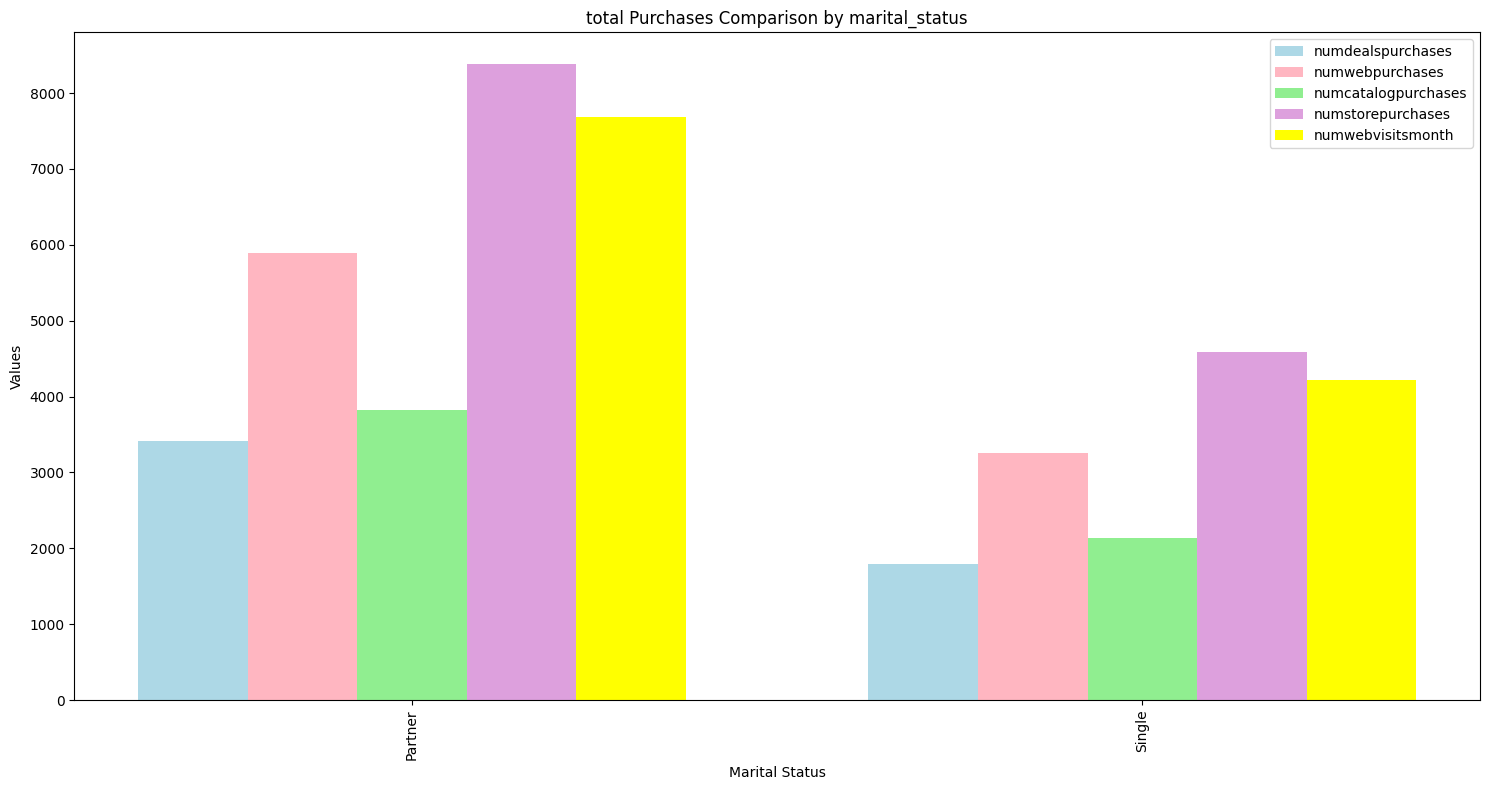

In [83]:
plt.figure(figsize=(15, 8))
bar_width = 0.15

xpos = np.arange(df_sum_pruchases.shape[0])

# Plot each bar with unique color and label
bars1 = plt.bar(xpos - 0.3, df_sum_pruchases.numdealspurchases, width=bar_width, label="numdealspurchases", color='lightblue')
bars2 = plt.bar(xpos - 0.15, df_sum_pruchases.numwebpurchases, width=bar_width, label="numwebpurchases", color='lightpink')
bars3 = plt.bar(xpos, df_sum_pruchases.numcatalogpurchases, width=bar_width, label="numcatalogpurchases", color='lightgreen')
bars4 = plt.bar(xpos + 0.15, df_sum_pruchases.numstorepurchases, width=bar_width, label="numstorepurchases", color='plum')
bars5 = plt.bar(xpos + 0.3, df_sum_pruchases.numwebvisitsmonth, width=bar_width, label="numwebvisitsmonth", color='yellow')

plt.xlabel('Marital Status')
plt.ylabel('Values')
plt.title('total Purchases Comparison by marital_status')

plt.xticks(xpos, df_sum_pruchases['marital_status'], rotation=90)
plt.legend()

plt.tight_layout()
plt.show()


### What is Max no of purchases according to Customer Marital Status ?

In [84]:
pruchases=data.groupby('marital_status',as_index=False)[['numdealspurchases', 'numwebpurchases','numcatalogpurchases','numstorepurchases','numwebvisitsmonth']].max()
df_pruchases=pd.DataFrame(pruchases)
df_pruchases


,marital_status,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth
0,Partner,15,25,28,13,20
1,Single,15,27,11,13,20


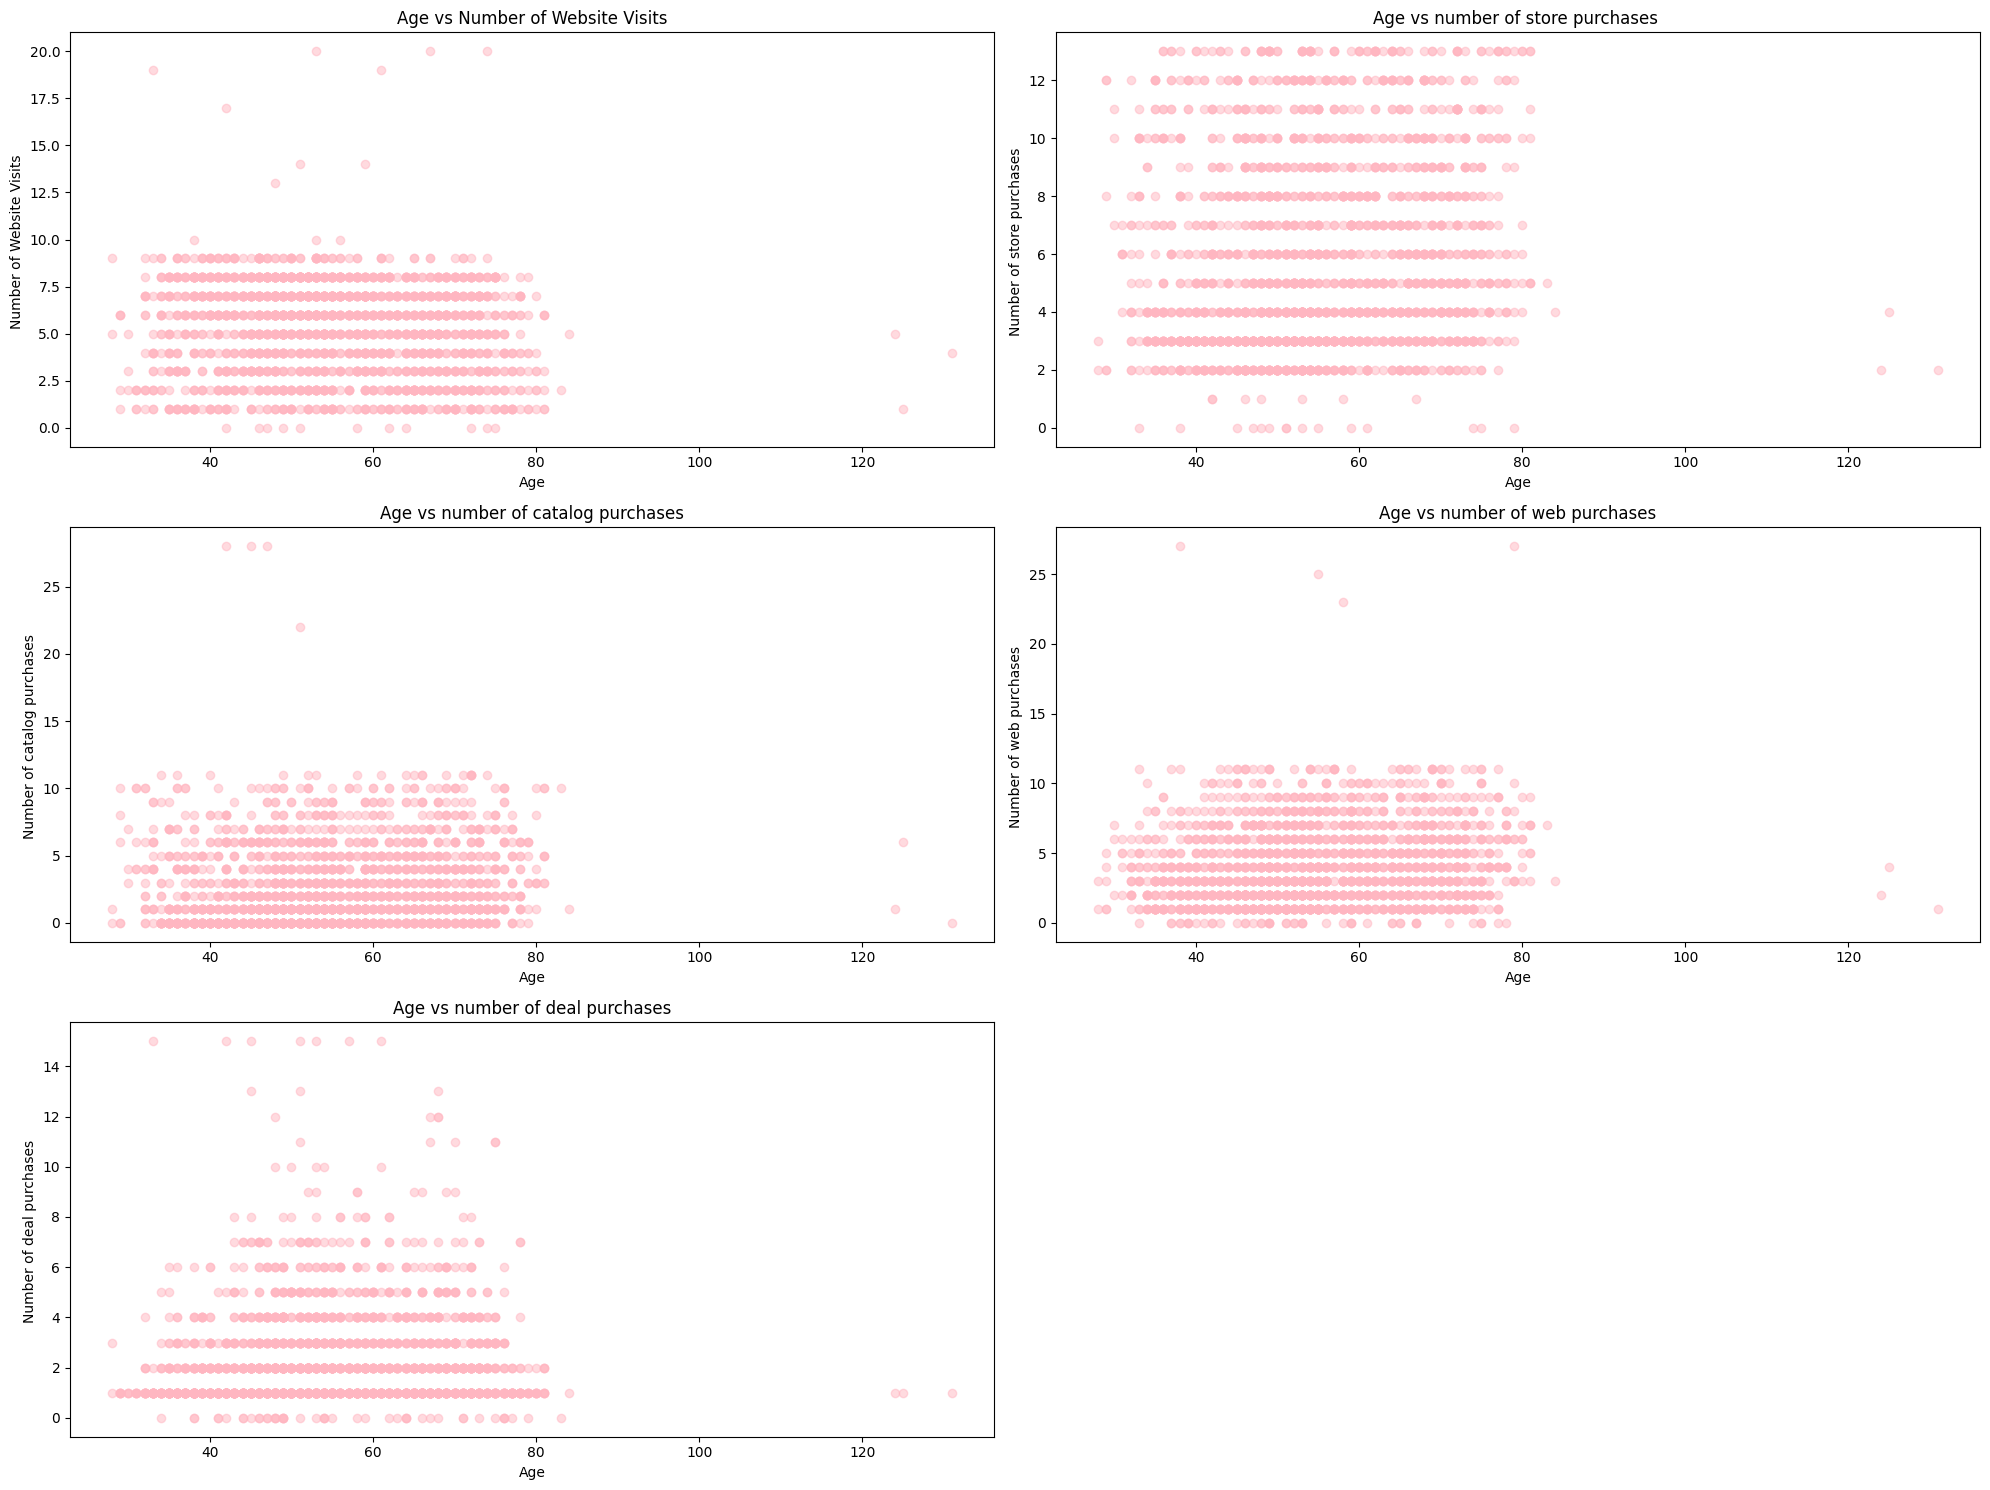

In [85]:
plt.figure(figsize=(20,15))

plt.subplot(3,2,1)
plt.scatter(data['age'], data['numwebvisitsmonth'], alpha=0.5, color='lightpink')

plt.title('Age vs Number of Website Visits')
plt.xlabel('Age')
plt.ylabel('Number of Website Visits ')

plt.subplot(3,2,2)
plt.scatter(data['age'], data['numstorepurchases'], alpha=0.5, color='lightpink')
plt.title('Age vs number of store purchases ')
plt.xlabel('Age')
plt.ylabel('Number of store purchases ')
plt.subplot(3,2,3)
plt.scatter(data['age'], data['numcatalogpurchases'], alpha=0.5, color='lightpink')

plt.title('Age vs number of catalog purchases')
plt.xlabel('Age')
plt.ylabel('Number of catalog purchases ')
plt.subplot(3,2,4)
plt.scatter(data['age'], data['numwebpurchases'], alpha=0.5, color='lightpink')
plt.title('Age vs number of web purchases')
plt.xlabel('Age')
plt.ylabel('Number of web purchases ')
plt.subplot(3,2,5)
plt.scatter(data['age'], data['numdealspurchases'], alpha=0.5, color='lightpink')

plt.title('Age vs number of deal purchases')
plt.xlabel('Age')
plt.ylabel('Number of deal purchases ')

plt.tight_layout()
plt.show()

In [86]:
sum_acceptedcmp=data.groupby('marital_status',as_index=False)[ ['acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2']].sum()
df_sum_acceptedcmp=pd.DataFrame(sum_acceptedcmp)
df_sum_acceptedcmp

,marital_status,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2
0,Partner,100,106,110,95,19
1,Single,63,61,53,49,11


### accepted cmp comparison according to Marital Status

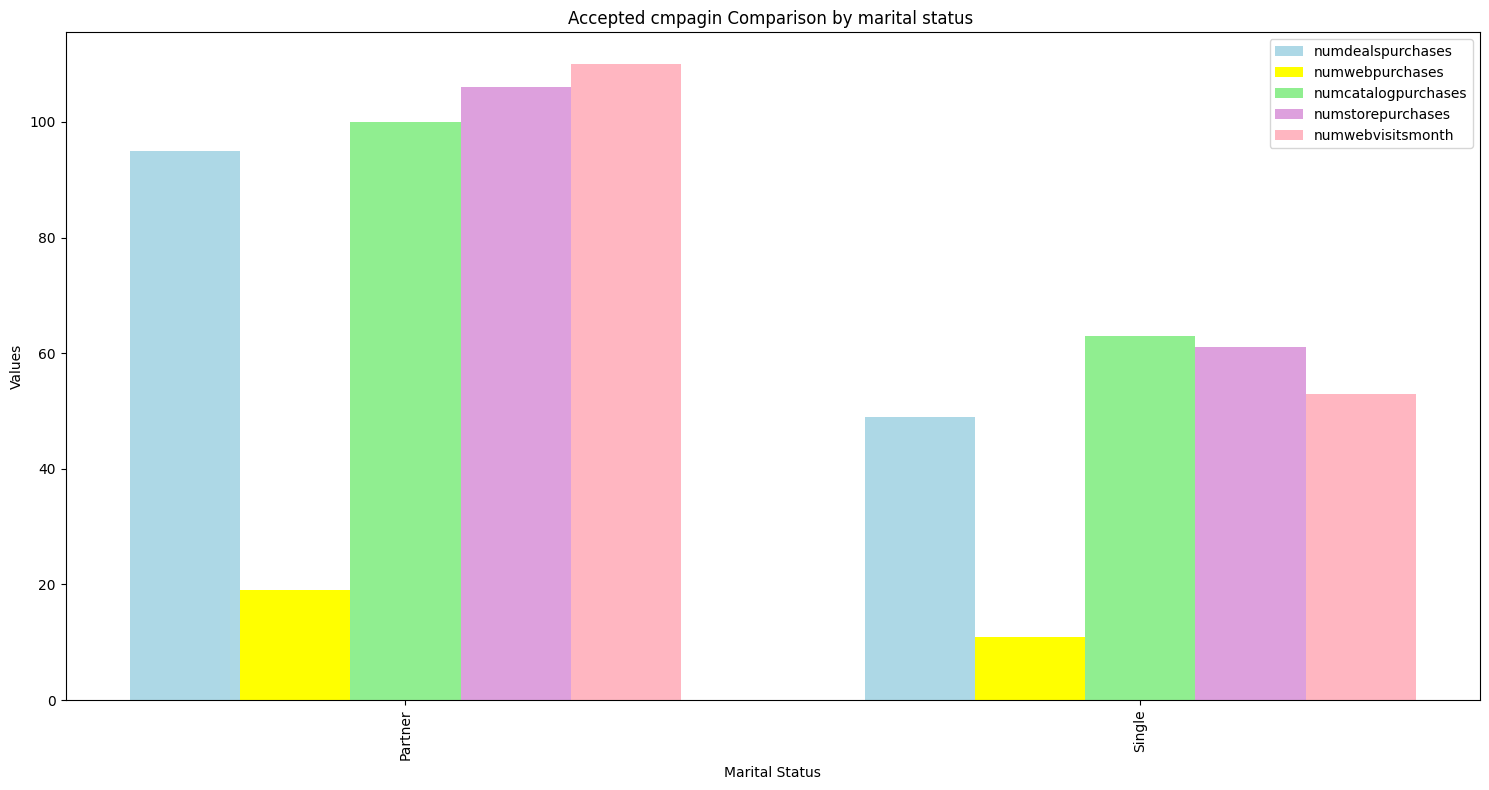

In [87]:
plt.figure(figsize=(15, 8))
bar_width = 0.15

xpos = np.arange(df_pruchases.shape[0])

bars1 = plt.bar(xpos - 0.3, df_sum_acceptedcmp.acceptedcmp1, width=bar_width, label="numdealspurchases", color='lightblue')
bars2 = plt.bar(xpos - 0.15, df_sum_acceptedcmp.acceptedcmp2, width=bar_width, label="numwebpurchases", color='yellow')
bars3 = plt.bar(xpos, df_sum_acceptedcmp.acceptedcmp3, width=bar_width, label="numcatalogpurchases", color='lightgreen')
bars4 = plt.bar(xpos + 0.15, df_sum_acceptedcmp.acceptedcmp4, width=bar_width, label="numstorepurchases", color='plum')
bars5 = plt.bar(xpos + 0.3, df_sum_acceptedcmp.acceptedcmp5, width=bar_width, label="numwebvisitsmonth", color='lightpink')

plt.xlabel('Marital Status')
plt.ylabel('Values')
plt.title('Accepted cmpagin Comparison by marital status ')

plt.xticks(xpos, df_sum_acceptedcmp['marital_status'], rotation=90)
plt.legend()

plt.tight_layout()
plt.show()


<div style="background-color: lightblue; padding: 20px; border-radius: 15px; border: 2px solid #F0F8FF; font-family: 'Arial', sans-serif; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">

<h2 style="text-align:center; color: #ffffff; font-size: 24px; font-weight: bold; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.3);">✂️Feature ENG  </h2>
<div>




In [88]:
col_del = ["year_birth","id","acceptedcmp1" ,'recency','complain', 'dt_customer',"acceptedcmp2", "acceptedcmp3" , "acceptedcmp4","acceptedcmp5","numwebvisitsmonth", "numwebpurchases","numcatalogpurchases","numstorepurchases","numdealspurchases" , "kidhome", "teenhome","mntwines", "mntfruits", "mntmeatproducts", "mntfishproducts", "mntsweetproducts", "mntgoldprods"]
new_data=data.drop(columns=col_del,axis=1)

<div style="background-color: lightblue; padding: 20px; border-radius: 15px; border: 2px solid #F0F8FF; font-family: 'Arial', sans-serif; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">

<h2 style="text-align:center; color: #ffffff; font-size: 24px; font-weight: bold; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.3);">⚠️Handel Outlires </h2>
<div>





<Axes: >

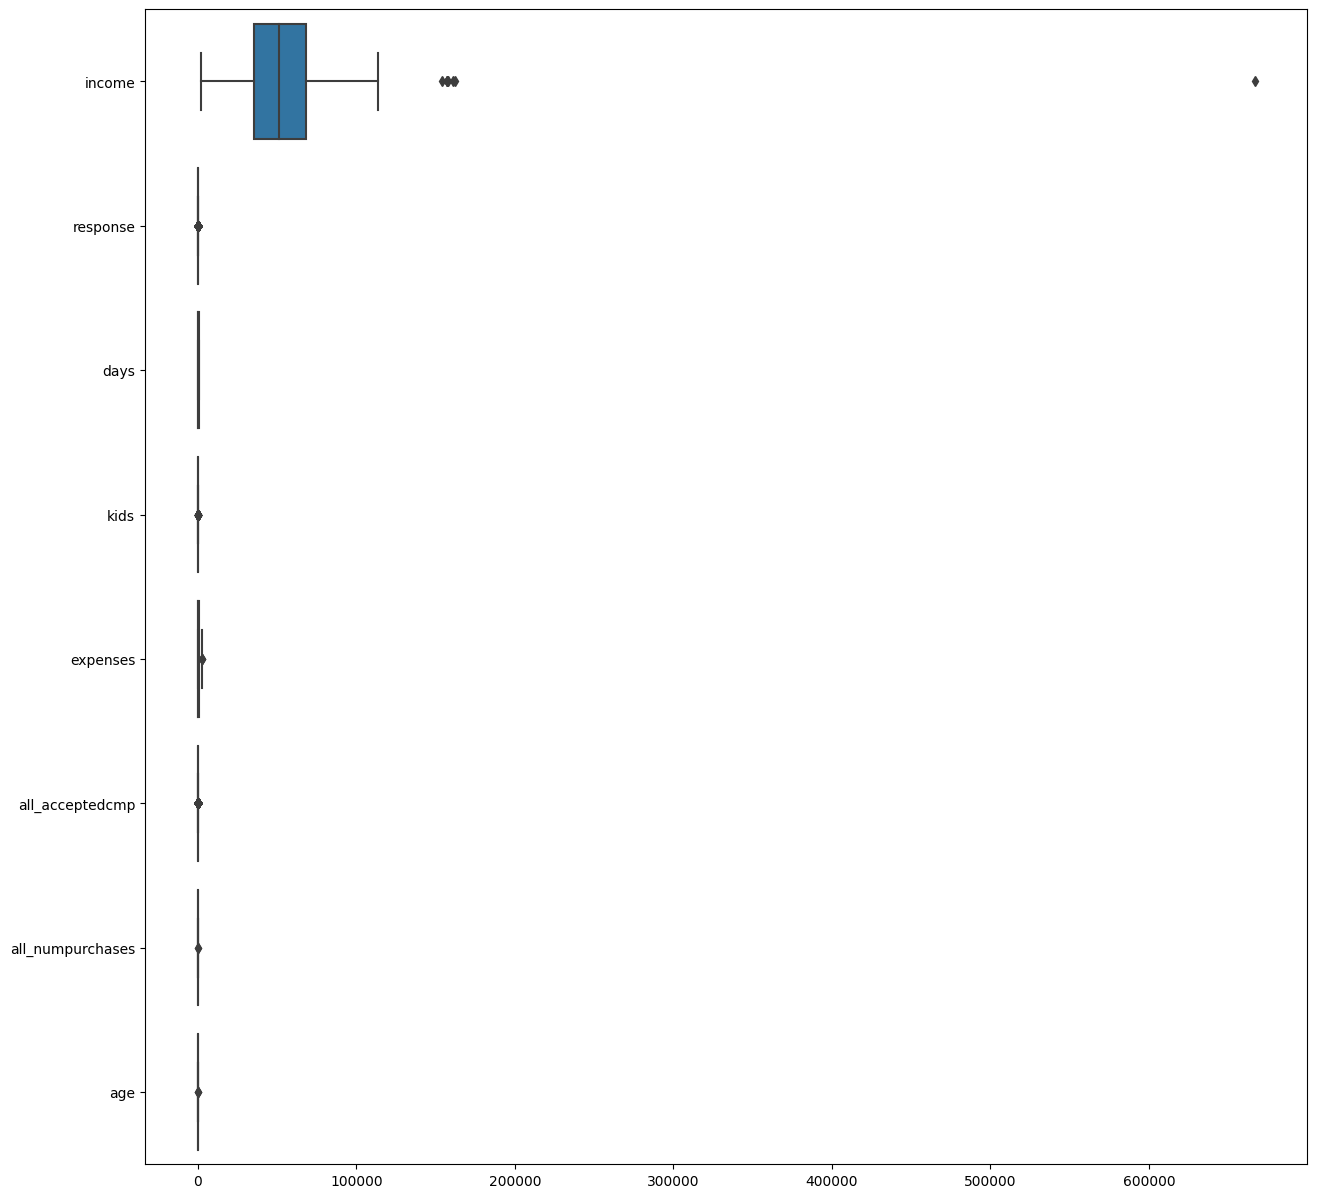

In [89]:
plt.figure(figsize=(15, 15))
sns.boxplot(new_data,orient='h')

In [90]:
num_col=new_data.select_dtypes(include='number').columns
num_col
z_scores = pd.DataFrame(zscore(new_data[num_col]), columns=num_col)
print(z_scores)

        income  response      days      kids  expenses  all_acceptedcmp  \
0     0.235696  2.388846  1.531185 -1.264505  1.679417        -0.439037   
1    -0.235454 -0.418612 -1.190545  1.396361 -0.961275        -0.439037   
2     0.773999 -0.418612 -0.205773 -1.264505  0.282673        -0.439037   
3    -1.022355 -0.418612 -1.061881  0.065928 -0.918094        -0.439037   
4     0.241888 -0.418612 -0.953012  0.065928 -0.305254        -0.439037   
...        ...       ...       ...       ...       ...              ...   
2235  0.358936 -0.418612  0.135680  0.065928  1.221032        -0.439037   
2236  0.470432 -0.418612 -1.655713  2.726794 -0.268717         1.035390   
2237  0.189476 -0.418612 -0.982703 -1.264505  1.054951         1.035390   
2238  0.679401 -0.418612 -0.977755  0.065928  0.393948        -0.439037   
2239  0.025208  2.388846  1.328292  1.396361 -0.720458        -0.439037   

      all_numpurchases       age  
0             1.320826  0.985345  
1            -1.154596  1.235

In [91]:
outliers = z_scores[(np.abs(z_scores) > 3).any(axis=1)]

# Drop the rows containing outliers
new_data = new_data.drop(outliers.index)

In [92]:
new_data

,education,marital_status,income,response,days,kids,expenses,all_acceptedcmp,all_numpurchases,age
0,Graduate,Single,58138.0,1,663,0,1617,0,25,67
1,Graduate,Single,46344.0,0,113,2,27,0,6,70
2,Graduate,Partner,71613.0,0,312,0,776,0,21,59
3,Graduate,Partner,26646.0,0,139,1,53,0,8,40
4,Postgraduate,Partner,58293.0,0,161,1,422,0,19,43
...,...,...,...,...,...,...,...,...,...,...
2235,Graduate,Partner,61223.0,0,381,1,1341,0,18,57
2236,Postgraduate,Partner,64014.0,0,19,3,444,1,22,78
2237,Graduate,Single,56981.0,0,155,0,1241,1,19,43
2238,Postgraduate,Partner,69245.0,0,156,1,843,0,23,68


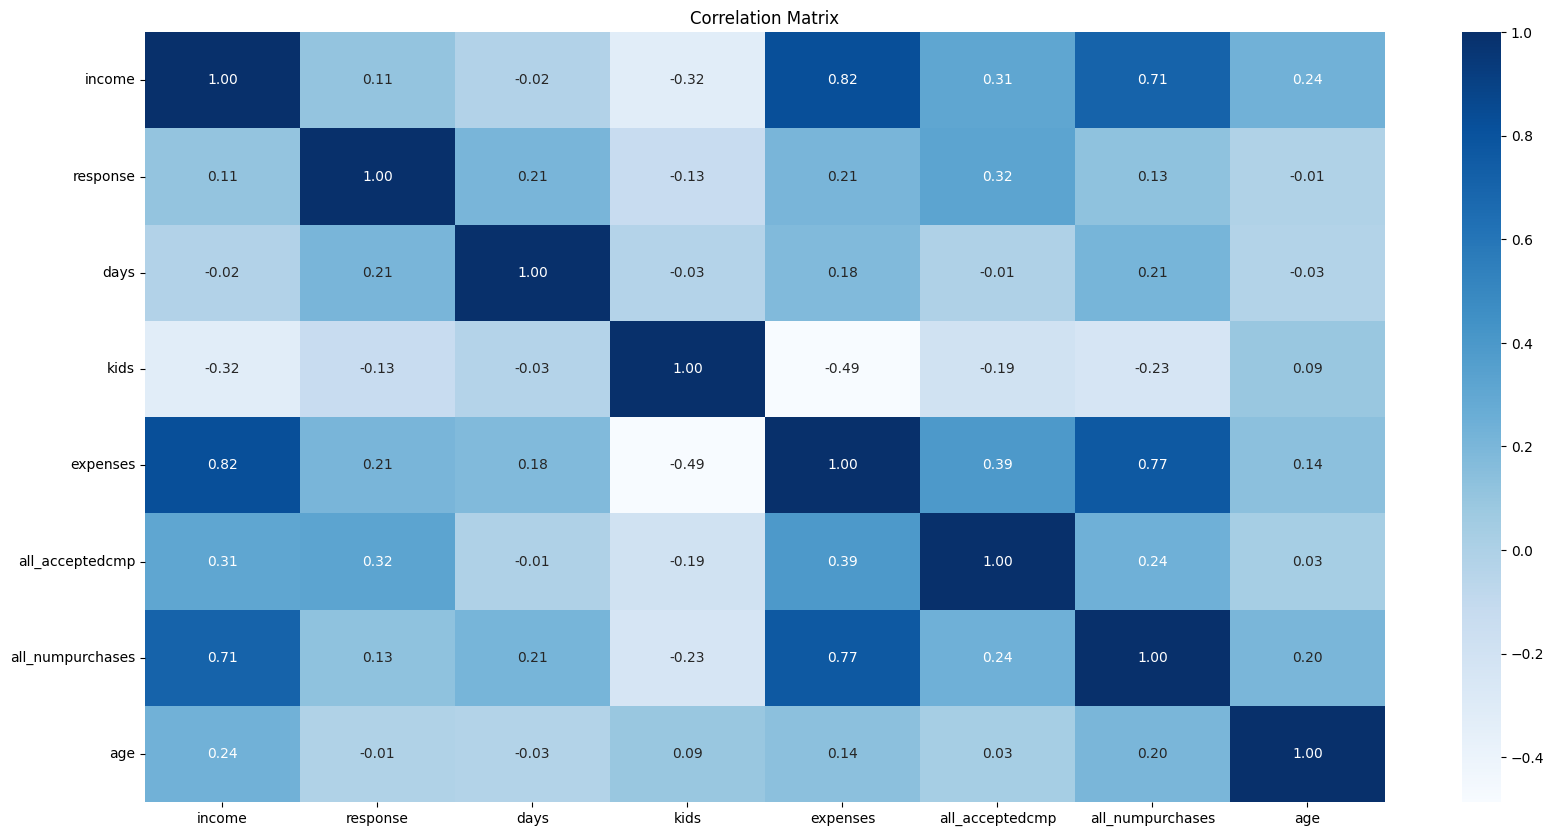

In [93]:
plt.figure(figsize=(20,10))
num_data=new_data.select_dtypes(include='number')
sns.heatmap(num_data.corr(),annot=True,fmt='.2f',cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

<div style="background-color: lightblue; padding: 20px; border-radius: 15px; border: 2px solid #F0F8FF; font-family: 'Arial', sans-serif; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">

<h2 style="text-align:center; color: #ffffff; font-size: 24px; font-weight: bold; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.3);">Categorical Encoding </h2>
<div>




In [94]:
le= LabelEncoder()  

new_data['education'] = le.fit_transform(new_data['education'])
new_data['marital_status'] = le.fit_transform(new_data['marital_status'])

<div style="background-color: lightblue; padding: 20px; border-radius: 15px; border: 2px solid #F0F8FF; font-family: 'Arial', sans-serif; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">

<h2 style="text-align:center; color: #ffffff; font-size: 24px; font-weight: bold; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.3);">📏Scale Data </h2>
<div>





In [95]:
scaler = StandardScaler()
col =['income','days','kids', 'expenses', 'all_acceptedcmp', 'all_numpurchases', 'age']
scaled_data = scaler.fit_transform(new_data[col])


In [96]:
new_data.head(10)

,education,marital_status,income,response,days,kids,expenses,all_acceptedcmp,all_numpurchases,age
0,0,1,58138.0,1,663,0,1617,0,25,67
1,0,1,46344.0,0,113,2,27,0,6,70
2,0,0,71613.0,0,312,0,776,0,21,59
3,0,0,26646.0,0,139,1,53,0,8,40
4,1,0,58293.0,0,161,1,422,0,19,43
5,1,0,62513.0,0,293,1,716,0,22,57
6,0,1,55635.0,0,593,1,590,0,21,53
7,1,0,33454.0,0,417,1,169,0,10,39
8,1,0,30351.0,1,388,1,46,0,6,50
9,1,0,5648.0,0,108,2,49,1,2,74


In [97]:
new_data.shape

(2169, 10)

<div style="background-color: lightblue; padding: 20px; border-radius: 15px; border: 2px solid #F0F8FF; font-family: 'Arial', sans-serif; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.2);">

<h2 style="text-align:center; color: #ffffff; font-size: 24px; font-weight: bold; text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.3);">Build Kmean Model</h2>
<div>




## 📉 Elbow Curve 

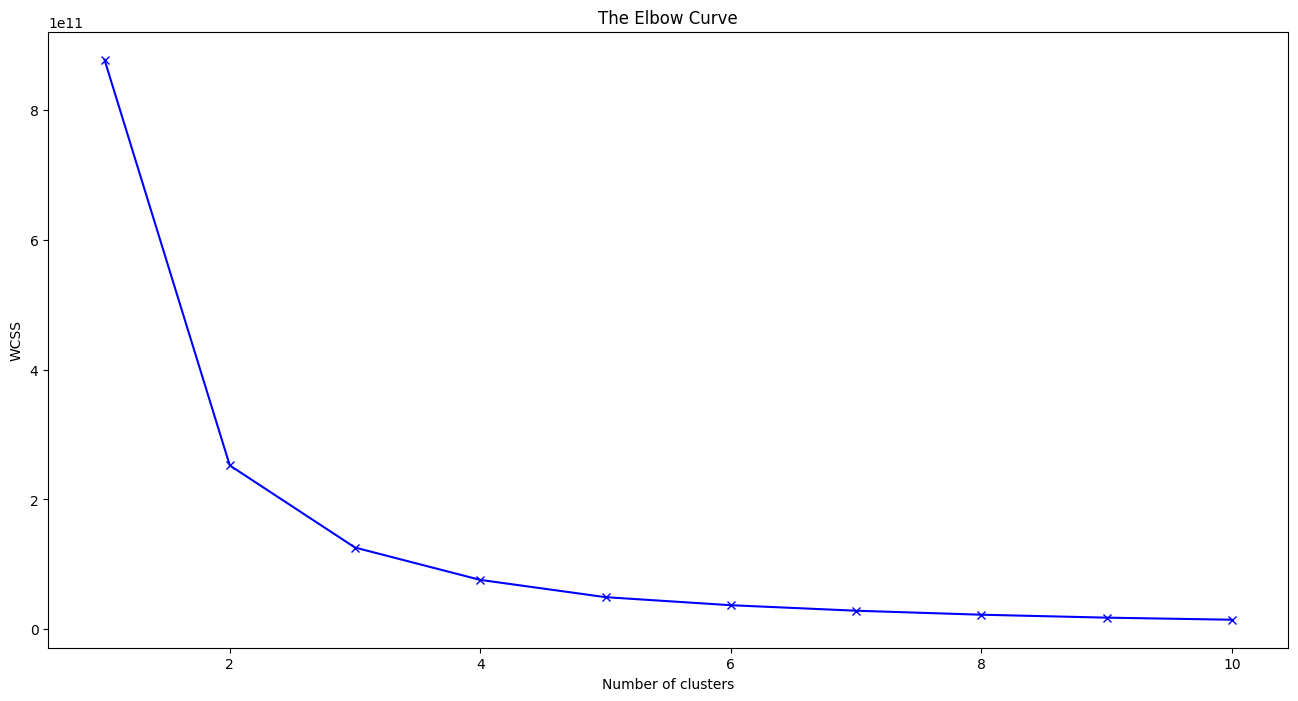

In [98]:
wcss=[]
for i in range (1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(new_data)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(16,8))
plt.plot(range(1,11),wcss, 'bx-')
plt.title('The Elbow Curve')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [99]:

kmeans=KMeans(n_clusters=2, random_state=42).fit(new_data)
pred=kmeans.predict(new_data)



new_data['cluster_Kmeans'] = pred + 1

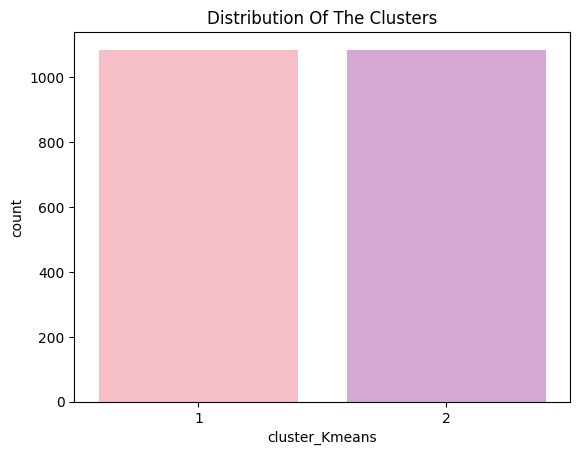

In [100]:
sns.countplot(x=new_data["cluster_Kmeans"], palette=[ 'lightpink', 'plum'])
plt.title("Distribution Of The Clusters")
plt.show()

In [101]:
fig = px.scatter(new_data, x='cluster_Kmeans',color='cluster_Kmeans',color_continuous_scale=['lightpink', 'plum'])
fig.show()

In [102]:
fig = px.scatter(new_data, x='expenses', y='income', color='cluster_Kmeans',
                 color_continuous_scale=['lightpink', 'plum'])
fig.show()


In [103]:
fig = px.scatter(new_data, x='kids', y='income', color='cluster_Kmeans',
                 color_continuous_scale=['lightpink', 'plum'])
fig.show()

In [104]:
fig = px.scatter(new_data, x='marital_status', y='income', color='cluster_Kmeans',
                 color_continuous_scale=['lightpink', 'plum'])
fig.show()

In [105]:
fig = px.scatter(new_data, x='marital_status', y='expenses', color='cluster_Kmeans',
                 color_continuous_scale=['lightpink', 'plum'])
fig.show()

In [106]:
new_data.columns 

Index(['education', 'marital_status', 'income', 'response', 'days', 'kids',
       'expenses', 'all_acceptedcmp', 'all_numpurchases', 'age',
       'cluster_Kmeans'],
      dtype='object')

In [107]:
fig = px.scatter(new_data, x='income', y='age', color='cluster_Kmeans',
                 color_continuous_scale=['lightpink', 'plum'])
fig.show()

<div style="background-color: #f7f9fc; padding: 20px; border-radius: 10px; border: 3px solid lightblue; font-family: Arial, sans-serif;">

<h2 style="text-align:center; color:#2c3e50;">🔍 Clusters Conclusions</h2>

<h3 style="color: #2980b9;">💡 Cluster 1:</h3>
<p style="font-size: 16px; color: #34495e;">
    <ul style="list-style-type: none; padding-left: 0;">
        <li>• <strong>People with less expenses</strong> 💵</li>
        <li>• People who are <strong>married</strong> 💍 and parents of <strong>more than 3 kids</strong> 👨‍👩‍👧‍👦</li>
        <li>• People with <strong>low income</strong> 📉</li>
    </ul>
</p>

<h3 style="color: #e67e22;">💡 Cluster 2:</h3>
<p style="font-size: 16px; color: #34495e;">
    <ul style="list-style-type: none; padding-left: 0;">
        <li>• <strong>People with more expenses</strong> 💸</li>
        <li>• People who are <strong>single</strong> 💔 or parents of <strong>less than 3 kids</strong> 👨‍👧</li>
        <li>• People with <strong>high income</strong> 📈</li>
    </ul>
</p>

<h3 style="color: #8e44ad;">📅 Age Observation:</h3>
<p style="font-size: 16px; color: #34495e;">
    Age is not the main criteria, but it is observed to some extent that <strong>older people</strong> 👵👴 tend to fall into this group (2).
</p>

<h3 style="color: #16a085;">🎯 Target:</h3>
<p style="font-size: 16px; color: #34495e;">
    <strong>Cluster 2</strong> represents higher spenders 💰 and can be strategically targeted by firms for product sales. 🎯
</p>

</div>
